## 📦 Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn joblib


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Gokul R\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score,
    recall_score, f1_score
)
from scipy.sparse import hstack

nltk.download('stopwords')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to C:\Users\Gokul
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 📂 Step 2: Load Dataset

In [4]:
df = pd.read_csv("spamAssasin.csv")
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nLabel Distribution:")
print(df['label'].value_counts())
df.head(3)

Dataset Shape: (5809, 7)

Column Names: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Label Distribution:
label
0    4091
1    1718
Name: count, dtype: int64


,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1


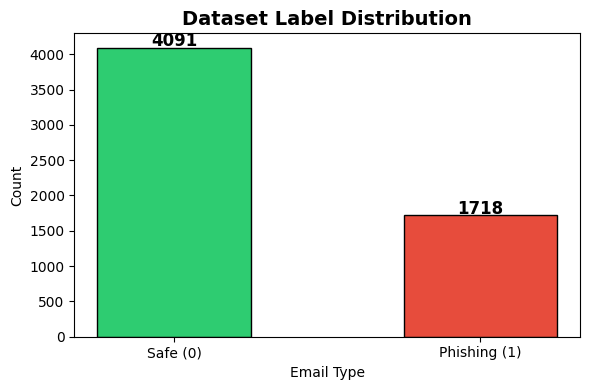

✅ Label distribution chart saved!


In [5]:
# Visualize label distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['label'].value_counts()
bars = ax.bar(['Safe (0)', 'Phishing (1)'], counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Dataset Label Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Email Type')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print("✅ Label distribution chart saved!")

## 🔧 Step 3: Text Preprocessing

In [6]:
# Combine subject + body
df['final_text'] = df['subject'].fillna('') + " " + df['body'].fillna('')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df['clean_text'] = df['final_text'].apply(preprocess_text)
print("✅ Text preprocessing complete!")
print("\nSample clean text:")
print(df['clean_text'].iloc[0][:200])

✅ Text preprocessing complete!

Sample clean text:
new sequenc window date wed aug chri garrigu messag tmda deepeddi vircio com reproduc error repeat like everi time without fail debug log pick happen pick exec pick inbox list lbrace lbrace subject ft


## 🧠 Step 4: Feature Engineering
Adding hand-crafted features to help models detect phishing patterns.

In [7]:
# Suspicious keywords — context-aware, not just word matches
# KEY FIX: words like 'password', 'account', 'update', 'confirm' are also
# common in LEGITIMATE emails (password reset confirmations, order updates).
# So we DON'T count them alone. Instead we use CONTEXT SCORING:
# a keyword only adds weight when combined with urgency/threat language.

PHISHING_KEYWORDS = [
    'urgent', 'verify', 'login', 'suspended', 'click here',
    'click the link', 'paypal', 'prize', 'winner', 'congratulations',
    'limited time', 'expire', 'unusual activity', 'restore access',
    'permanent closure', 'permanently locked', 'immediately',
    'act now', 'do not share', 'send your details',
    'bank details', 'id proof', 'personal details',
    'lottery', 'selected', 'lucky winner', 'claim your'
]

# These are HIGH-RISK words only when a URL is also present
URL_DEPENDENT_KEYWORDS = [
    'verify', 'confirm', 'update your', 'restore', 'reactivate',
    'validate', 'click below', 'click here'
]

# These words in subject lines are strong phishing signals
PHISHING_SUBJECT_WORDS = [
    'urgent', 'suspended', 'compromised', 'unauthorized',
    'verify now', 'action required', 'your account', 'congratulations',
    'you have won', 'lottery', 'job offer', 'delivery failed'
]

# Legitimate-context words — presence of THESE reduces phishing score
SAFE_CONTEXT_WORDS = [
    'timetable', 'schedule', 'uploaded', 'portal', 'reminder',
    'meeting', 'agenda', 'newsletter', 'weekly', 'order confirmed',
    'order #', 'track your order', 'password was changed',
    'successfully updated', 'successfully placed', 'shopping',
    'exam', 'semester', 'academic', 'lecture', 'result'
]

def extract_features(text):
    text = str(text)
    text_lower = text.lower()

    # Split subject from body if present
    subject = ""
    body = text_lower
    if "subject:" in text_lower:
        parts = text_lower.split("\n", 1)
        subject = parts[0].replace("subject:", "").strip()
        body = parts[1] if len(parts) > 1 else text_lower

    # 1. Number of URLs/links
    num_links = len(re.findall(r'http[s]?://|www\.', text_lower))

    # 2. Phishing keyword score (context-aware)
    # Direct keyword matches
    direct_matches = sum(1 for kw in PHISHING_KEYWORDS if kw in text_lower)

    # URL-dependent keywords only count if there's also a link
    url_dep_matches = 0
    if num_links > 0:
        url_dep_matches = sum(1 for kw in URL_DEPENDENT_KEYWORDS if kw in text_lower)

    # Subject-line phishing words are extra strong signal
    subject_matches = sum(1 for kw in PHISHING_SUBJECT_WORDS if kw in subject)

    # Safe context reduces score — emails with scheduling/order/legit words
    safe_penalty = sum(1 for kw in SAFE_CONTEXT_WORDS if kw in text_lower)

    num_suspicious_words = max(0, direct_matches + url_dep_matches + subject_matches - safe_penalty)

    # 3. Email/text length (character count)
    email_length = len(text)

    # 4. Special character count (@, !, $, #, %)
    special_chars = len(re.findall(r'[@!\$#%]', text))

    # 5. Number of digits — but normalize: order numbers are expected
    num_digits = len(re.findall(r'\d', text))
    # Order-number pattern is safe — reduce digit score if order # present
    if re.search(r'order\s*#\s*\d+|order\s+number\s+\d+', text_lower):
        num_digits = max(0, num_digits - 5)

    # 6. Uppercase ratio (phishing often SHOUTS)
    alpha_chars = [c for c in text if c.isalpha()]
    upper_ratio = sum(1 for c in alpha_chars if c.isupper()) / (len(alpha_chars) + 1)

    # 7. Exclamation mark count
    exclamation_count = text.count('!')

    # 8. Suspicious URL domain score (new feature)
    suspicious_url_score = 0
    urls = re.findall(r'https?://([^\s/]+)', text_lower)
    for domain in urls:
        if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', domain):  # IP
            suspicious_url_score += 3
        if any(kw in domain for kw in ['secure','login','verify','paypal','bank','account']):
            suspicious_url_score += 2
        if any(domain.endswith(ext) for ext in ['.xyz','.net','.info','.tk','.ml']):
            suspicious_url_score += 1
        if domain.count('-') >= 2:  # multiple hyphens = suspicious
            suspicious_url_score += 1

    return [
        num_links, num_suspicious_words, email_length,
        special_chars, num_digits, upper_ratio, exclamation_count,
        suspicious_url_score
    ]

FEATURE_NAMES = [
    'num_links', 'num_suspicious_words', 'email_length',
    'special_chars', 'num_digits', 'upper_ratio',
    'exclamation_count', 'suspicious_url_score'
]

feature_matrix = np.array([extract_features(text) for text in df['final_text']])
df_features = pd.DataFrame(feature_matrix, columns=FEATURE_NAMES)

print("✅ Feature engineering complete!")
print("\nEngineered Features — Phishing vs Safe (mean values):")
df_compare = df_features.copy()
df_compare['label'] = df['label'].values
print(df_compare.groupby('label')[FEATURE_NAMES].mean().round(3))

✅ Feature engineering complete!

Engineered Features — Phishing vs Safe (mean values):
       num_links  num_suspicious_words  email_length  special_chars  \
label                                                                 
0          7.442                 0.094      2077.673          7.440   
1          3.692                 0.767      3319.718         14.654   

       num_digits  upper_ratio  exclamation_count  suspicious_url_score  
label                                                                    
0          50.811        0.066              2.757                 0.587  
1         195.860        0.157              6.483                 0.895  


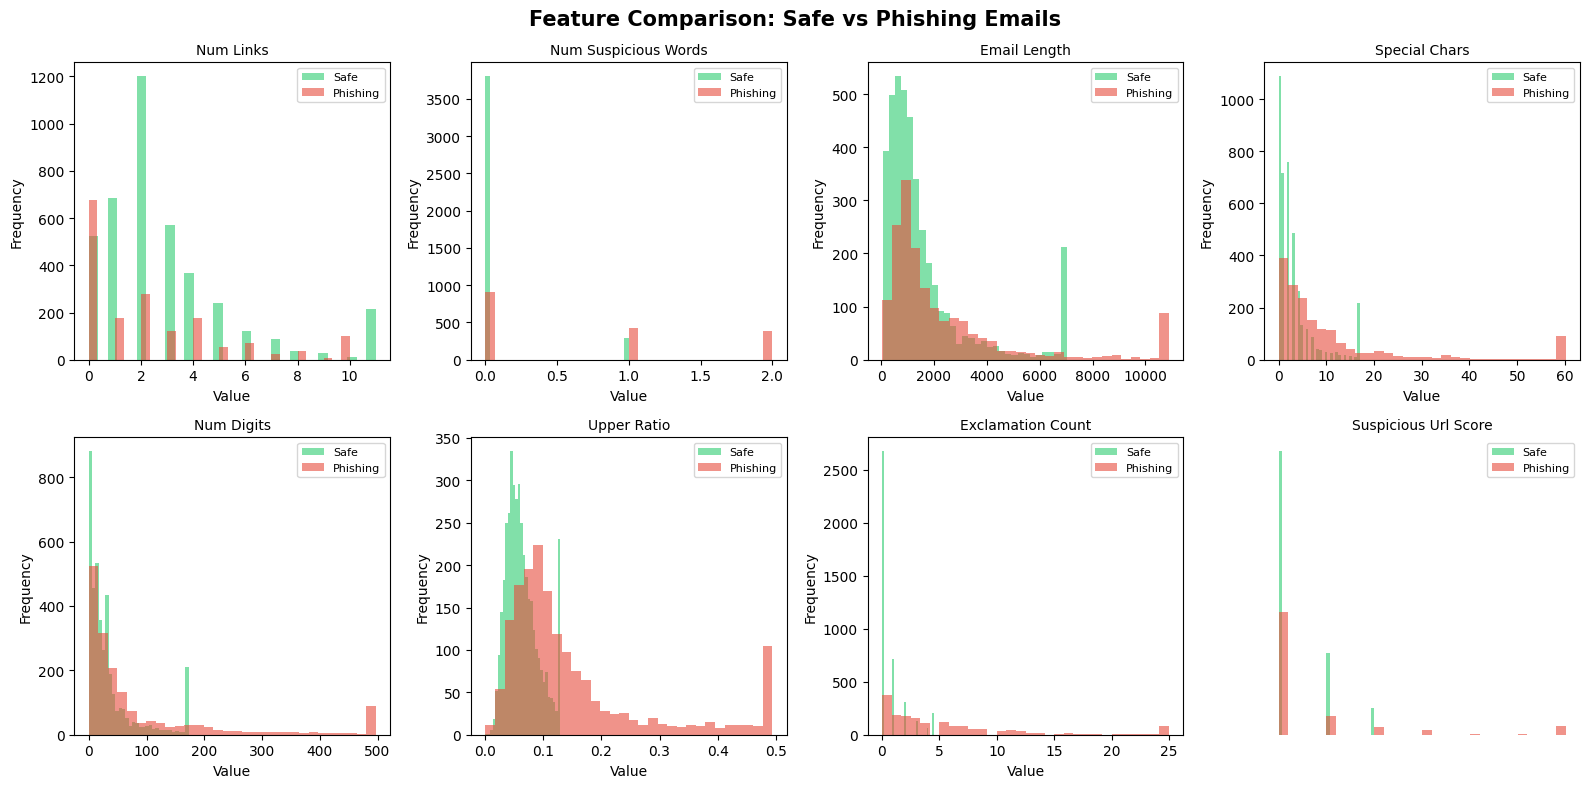

✅ Feature comparison chart saved!


In [8]:
# Visualize feature differences between safe and phishing emails
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Comparison: Safe vs Phishing Emails', fontsize=15, fontweight='bold')
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c']
labels = ['Safe', 'Phishing']

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    for label_val, color, label_name in zip([0, 1], colors, labels):
        data = df_compare[df_compare['label'] == label_val][feat]
        # Cap at 95th percentile for readability
        cap = data.quantile(0.95)
        data = data.clip(upper=cap)
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label_name)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

axes[-1].axis('off')  # hide last empty subplot
plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
plt.show()
print("✅ Feature comparison chart saved!")

## ✂️ Step 5: Train-Test Split & TF-IDF Vectorization

In [9]:
X_text = df['clean_text']
X_feat = feature_matrix
y = df['label']

# Split indices
X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_text, X_feat, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF on text
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf  = tfidf.transform(X_text_test)

# Combine TF-IDF + engineered features
from scipy.sparse import csr_matrix
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_feat_train)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_feat_test)])

print(f"✅ Train size: {X_train_combined.shape}")
print(f"✅ Test size:  {X_test_combined.shape}")

✅ Train size: (4647, 5008)
✅ Test size:  (1162, 5008)


## 🤖 Step 6: Train All Models

In [10]:
models = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 LinearSVC(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Naive Bayes needs non-negative input, so use only TF-IDF for it
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    if name == 'Naive Bayes':
        # MultinomialNB requires non-negative features — use TF-IDF only
        model.fit(X_train_tfidf, y_train)
        preds = model.predict(X_test_tfidf)
    else:
        model.fit(X_train_combined, y_train)
        preds = model.predict(X_test_combined)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)
    cm   = confusion_matrix(y_test, preds)

    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1,
        'Confusion Matrix': cm, 'Predictions': preds
    }
    trained_models[name] = model

    print(f"   ✅ Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

print("\n🎉 All models trained successfully!")


🔄 Training Naive Bayes...
   ✅ Accuracy: 0.9750 | Precision: 0.9539 | Recall: 0.9622 | F1: 0.9580

🔄 Training Logistic Regression...
   ✅ Accuracy: 0.9561 | Precision: 0.9536 | Recall: 0.8953 | F1: 0.9235

🔄 Training SVM...
   ✅ Accuracy: 0.7849 | Precision: 0.9519 | Recall: 0.2878 | F1: 0.4420

🔄 Training Random Forest...
   ✅ Accuracy: 0.9759 | Precision: 0.9731 | Recall: 0.9448 | F1: 0.9587

🎉 All models trained successfully!


## 📊 Step 7: Model Comparison Table

In [11]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy':  round(r['Accuracy'], 4),
        'Precision': round(r['Precision'], 4),
        'Recall':    round(r['Recall'], 4),
        'F1-Score':  round(r['F1-Score'], 4)
    }
    for name, r in results.items()
}).T

print("\n📋 MODEL COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string())
print("=" * 60)
print(f"\n🏆 Best Model by F1-Score: {comparison_df['F1-Score'].idxmax()}")


📋 MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Naive Bayes            0.9750     0.9539  0.9622    0.9580
Logistic Regression    0.9561     0.9536  0.8953    0.9235
SVM                    0.7849     0.9519  0.2878    0.4420
Random Forest          0.9759     0.9731  0.9448    0.9587

🏆 Best Model by F1-Score: Random Forest


## 📈 Step 8: Accuracy Comparison Bar Chart

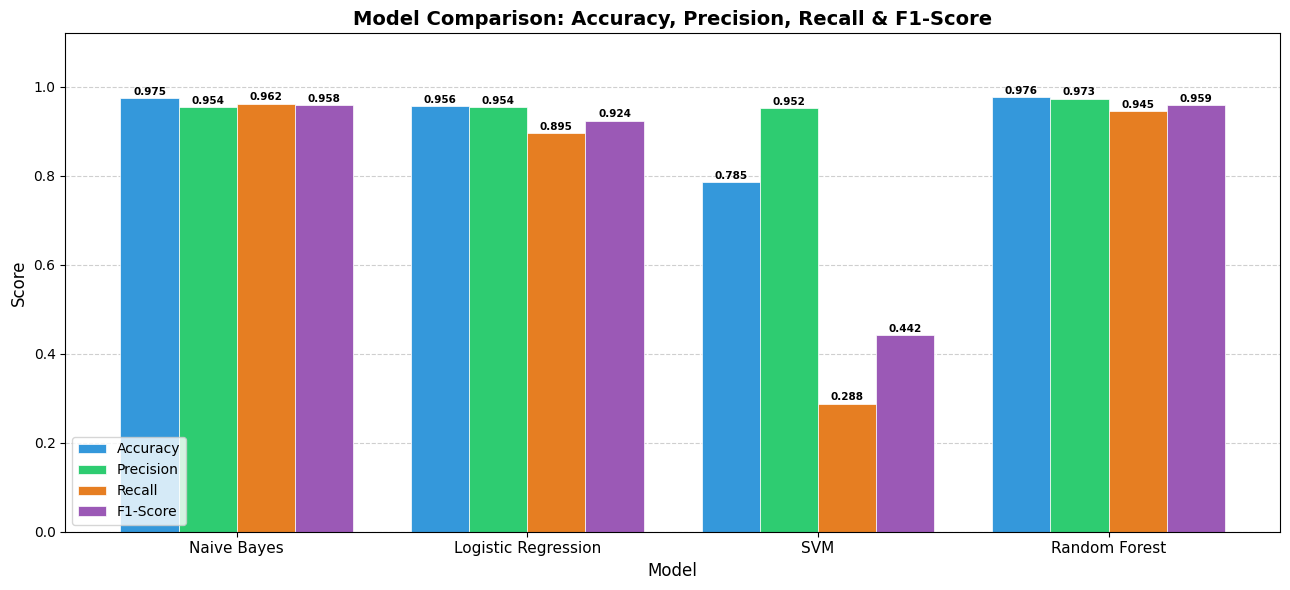

✅ Model comparison chart saved!


In [12]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.2
bar_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy, Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("✅ Model comparison chart saved!")

## 🔲 Step 9: Confusion Matrix Heatmaps

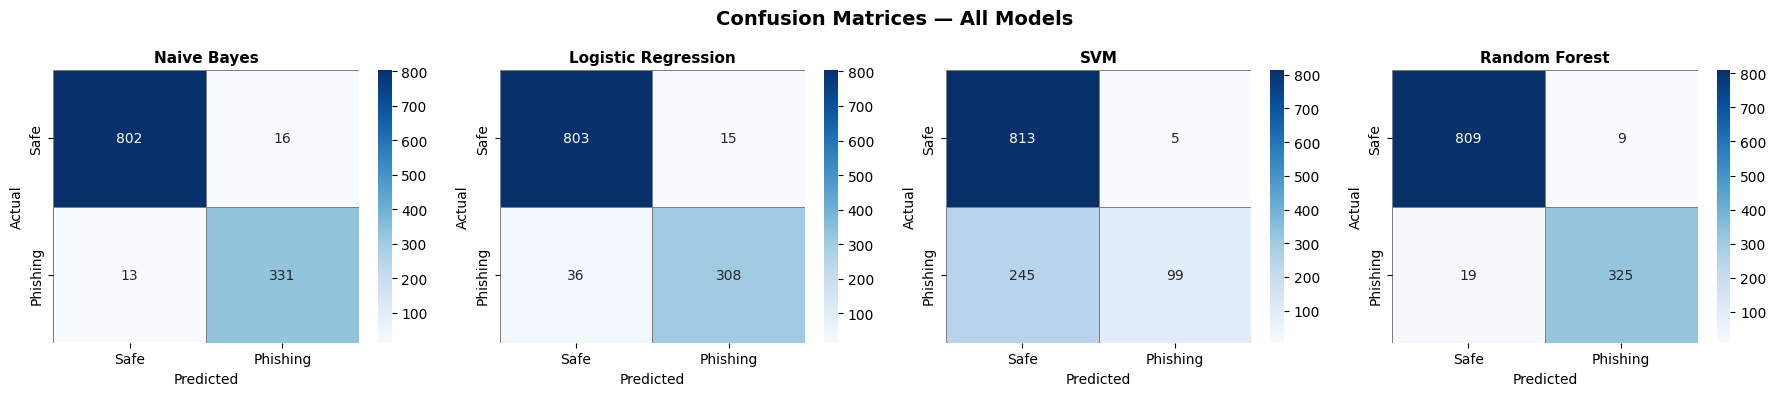

✅ Confusion matrix heatmaps saved!


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = r['Confusion Matrix']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Safe', 'Phishing'],
        yticklabels=['Safe', 'Phishing'],
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrix heatmaps saved!")

## 🔍 Step 10: Explainable AI — Top Phishing Trigger Words

In [14]:
# Use Logistic Regression coefficients to find top phishing words
lr_model = trained_models['Logistic Regression']
feature_names_tfidf = tfidf.get_feature_names_out()
# LR was trained on combined features; take only TF-IDF portion (first 5000 weights)
lr_coefs = lr_model.coef_[0][:len(feature_names_tfidf)]

TOP_N = 20
top_phishing_idx = np.argsort(lr_coefs)[-TOP_N:][::-1]
top_safe_idx     = np.argsort(lr_coefs)[:TOP_N]

top_phishing_words = [(feature_names_tfidf[i], lr_coefs[i]) for i in top_phishing_idx]
top_safe_words     = [(feature_names_tfidf[i], lr_coefs[i]) for i in top_safe_idx]

print("🚨 TOP 20 WORDS THAT TRIGGER PHISHING DETECTION:")
print("-" * 40)
for word, score in top_phishing_words:
    print(f"  {word:<25} score: {score:.4f}")

print("\n✅ TOP 20 WORDS THAT INDICATE SAFE EMAIL:")
print("-" * 40)
for word, score in top_safe_words:
    print(f"  {word:<25} score: {score:.4f}")

🚨 TOP 20 WORDS THAT TRIGGER PHISHING DETECTION:
----------------------------------------
  free                      score: 3.2875
  remov                     score: 3.2125
  pleas                     score: 2.7055
  email                     score: 2.0339
  credit                    score: 1.9885
  money                     score: 1.9582
  busi                      score: 1.9507
  spamassassin sight        score: 1.9499
  rate                      score: 1.8995
  receiv                    score: 1.8502
  sight                     score: 1.8228
  compani                   score: 1.8033
  click                     score: 1.7358
  offer                     score: 1.6890
  market                    score: 1.6621
  mortgag                   score: 1.5030
  opportun                  score: 1.4241
  invest                    score: 1.4213
  site                      score: 1.4160
  nextpart                  score: 1.3969

✅ TOP 20 WORDS THAT INDICATE SAFE EMAIL:
-----------------------------

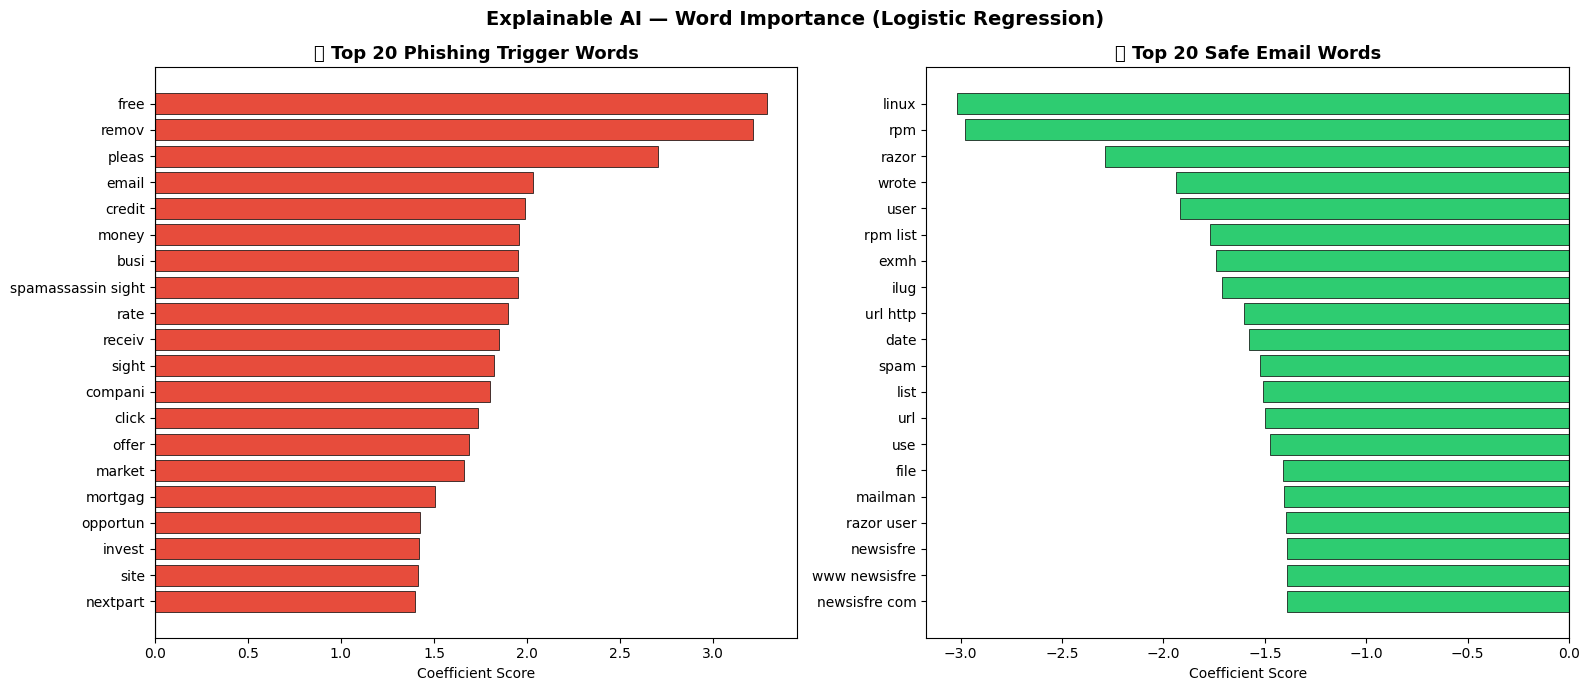

✅ Explainable AI chart saved!


In [15]:
# Visualize top phishing & safe words
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

phishing_words_list = [w for w, _ in top_phishing_words]
phishing_scores     = [s for _, s in top_phishing_words]
ax1.barh(phishing_words_list[::-1], phishing_scores[::-1], color='#e74c3c', edgecolor='black', linewidth=0.5)
ax1.set_title('🚨 Top 20 Phishing Trigger Words', fontsize=13, fontweight='bold')
ax1.set_xlabel('Coefficient Score')
ax1.axvline(0, color='black', linewidth=0.8)

safe_words_list = [w for w, _ in top_safe_words]
safe_scores     = [s for _, s in top_safe_words]
ax2.barh(safe_words_list[::-1], safe_scores[::-1], color='#2ecc71', edgecolor='black', linewidth=0.5)
ax2.set_title('✅ Top 20 Safe Email Words', fontsize=13, fontweight='bold')
ax2.set_xlabel('Coefficient Score')
ax2.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Explainable AI — Word Importance (Logistic Regression)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('explainable_ai_words.png', dpi=150)
plt.show()
print("✅ Explainable AI chart saved!")

## 🌐 Step 11: URL Suspicion Detector

In [16]:
def extract_urls(text):
    """Extract all URLs from email text."""
    url_pattern = r'https?://[^\s<>"{}|\\^`\[\]]+|www\.[^\s<>"{}|\\^`\[\]]+'
    return re.findall(url_pattern, str(text))

def is_url_suspicious(url):
    """Check if a URL has suspicious characteristics."""
    flags = []

    # Too long
    if len(url) > 75:
        flags.append("URL is too long (>75 chars)")

    # Contains IP address instead of domain
    if re.search(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url):
        flags.append("Uses IP address instead of domain name")

    # Multiple subdomains
    domain_part = re.sub(r'https?://', '', url).split('/')[0]
    if domain_part.count('.') > 3:
        flags.append("Too many subdomains (possible spoofing)")

    # Contains '@' symbol (redirect trick)
    if '@' in url:
        flags.append("Contains '@' symbol (redirect trick)")

    # Contains digits in domain
    if re.search(r'\d{4,}', domain_part):
        flags.append("Domain contains suspicious numbers")

    # Suspicious keywords in URL
    suspicious_url_words = ['login', 'verify', 'secure', 'account', 'update', 'confirm', 'paypal', 'bank']
    found = [w for w in suspicious_url_words if w in url.lower()]
    if found:
        flags.append(f"Suspicious keywords in URL: {', '.join(found)}")

    # URL shorteners
    shorteners = ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'buff.ly', 'short.link']
    if any(s in url.lower() for s in shorteners):
        flags.append("Uses URL shortener (hides real destination)")

    return flags

def analyze_urls_in_email(email_text):
    """Full URL analysis for an email."""
    urls = extract_urls(email_text)
    if not urls:
        return {"total_urls": 0, "suspicious_urls": [], "safe_urls": [], "risk_level": "LOW"}

    suspicious = []
    safe = []
    for url in urls:
        flags = is_url_suspicious(url)
        if flags:
            suspicious.append({"url": url, "reasons": flags})
        else:
            safe.append(url)

    ratio = len(suspicious) / len(urls)
    risk  = "HIGH" if ratio > 0.5 else "MEDIUM" if ratio > 0 else "LOW"

    return {
        "total_urls": len(urls),
        "suspicious_urls": suspicious,
        "safe_urls": safe,
        "risk_level": risk
    }

# Quick test
test_url_email = """
Dear Customer, your account needs verification!
Please click: http://192.168.1.1/secure-login/verify?id=123456789
Or visit: http://bit.ly/xY9k2m to confirm your paypal account.
Also see: https://www.google.com for more info.
"""
url_result = analyze_urls_in_email(test_url_email)
print("🌐 URL ANALYSIS DEMO")
print(f"Total URLs: {url_result['total_urls']}")
print(f"Risk Level: {url_result['risk_level']}")
print(f"\nSuspicious URLs ({len(url_result['suspicious_urls'])}):'")
for item in url_result['suspicious_urls']:
    print(f"  🔴 {item['url'][:60]}")
    for r in item['reasons']:
        print(f"     → {r}")
print(f"\nSafe URLs ({len(url_result['safe_urls'])}):")
for u in url_result['safe_urls']:
    print(f"  ✅ {u}")

🌐 URL ANALYSIS DEMO
Total URLs: 3
Risk Level: HIGH

Suspicious URLs (2):'
  🔴 http://192.168.1.1/secure-login/verify?id=123456789
     → Uses IP address instead of domain name
     → Suspicious keywords in URL: login, verify, secure
  🔴 http://bit.ly/xY9k2m
     → Uses URL shortener (hides real destination)

Safe URLs (1):
  ✅ https://www.google.com


## 🔮 Step 12: Real-Time Email Prediction
Paste any email text below and get an instant prediction with explanation.

In [17]:
# Pick best model (by F1)
best_model_name = comparison_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
print(f"🏆 Using best model: {best_model_name}")

def explain_prediction(email_text, top_n=10):
    """Show which words triggered the phishing detection."""
    lr = trained_models['Logistic Regression']
    text_vec = tfidf.transform([preprocess_text(email_text)])
    feature_names_arr = tfidf.get_feature_names_out()
    coefs = lr.coef_[0][:len(feature_names_arr)]

    text_arr  = text_vec.toarray()[0]
    word_scores = [(feature_names_arr[i], coefs[i], text_arr[i])
                   for i in range(len(feature_names_arr)) if text_arr[i] > 0]
    word_scores.sort(key=lambda x: x[1], reverse=True)

    return word_scores[:top_n]

def predict_email(email_text, verbose=True):
    """
    Predict whether an email is phishing or safe.
    Returns: dict with prediction, confidence, explanation, URL analysis
    """
    # Preprocess
    cleaned = preprocess_text(email_text)
    text_tfidf = tfidf.transform([cleaned])

    # Engineered features (now 8 features)
    eng_feats = np.array(extract_features(email_text)).reshape(1, -1)

    # Predict
    if best_model_name == 'Naive Bayes':
        pred = best_model.predict(text_tfidf)[0]
        try:
            proba = best_model.predict_proba(text_tfidf)[0]
            confidence = max(proba) * 100
        except:
            confidence = None
    else:
        from scipy.sparse import csr_matrix
        combined = hstack([text_tfidf, csr_matrix(eng_feats)])
        pred = best_model.predict(combined)[0]
        try:
            proba = best_model.predict_proba(combined)[0]
            confidence = max(proba) * 100
        except:
            confidence = None

    # Explanation
    trigger_words = explain_prediction(email_text)
    phishing_triggers = [(w, s) for w, s, _ in trigger_words if s > 0]

    # Matched keyword explanation
    text_lower = email_text.lower()
    matched_phishing_kws = [kw for kw in PHISHING_KEYWORDS if kw in text_lower]
    matched_safe_kws = [kw for kw in SAFE_CONTEXT_WORDS if kw in text_lower]

    # URL analysis
    url_analysis = analyze_urls_in_email(email_text)

    # Engineered feature values
    eng_dict = dict(zip(FEATURE_NAMES, eng_feats[0]))

    result = {
        'prediction': 'PHISHING 🚨' if pred == 1 else 'SAFE ✅',
        'label': pred,
        'confidence': confidence,
        'trigger_words': phishing_triggers[:10],
        'matched_phishing_keywords': matched_phishing_kws,
        'matched_safe_keywords': matched_safe_kws,
        'url_analysis': url_analysis,
        'features': eng_dict
    }

    if verbose:
        sep = "=" * 60
        print(sep)
        print(f"  📧 EMAIL PREDICTION RESULT")
        print(sep)
        print(f"  Result     : {result['prediction']}")
        if confidence:
            print(f"  Confidence : {confidence:.1f}%")
        print(f"  Model Used : {best_model_name}")
        print()
        print("  📊 Engineered Features:")
        for k, v in eng_dict.items():
            print(f"    {k:<28}: {v:.3f}")
        print()
        if matched_phishing_kws:
            print(f"  🚨 Phishing keywords found: {matched_phishing_kws}")
        if matched_safe_kws:
            print(f"  ✅ Safe context words found: {matched_safe_kws}")
        if phishing_triggers:
            print(f"  🔑 Top TF-IDF Trigger Words:")
            for w, s in phishing_triggers[:8]:
                print(f"    '{w}' (score: {s:.4f})")
        print()
        print(f"  🌐 URL Analysis:")
        print(f"    Total URLs     : {url_analysis['total_urls']}")
        print(f"    Suspicious URLs: {len(url_analysis['suspicious_urls'])}")
        print(f"    URL Risk Level : {url_analysis['risk_level']}")
        if url_analysis['suspicious_urls']:
            for item in url_analysis['suspicious_urls']:
                print(f"    🔴 {item['url'][:50]}")
                for r in item['reasons'][:2]:
                    print(f"       → {r}")
        print(sep)

    return result

print("✅ Real-time prediction function ready!")

🏆 Using best model: Random Forest
✅ Real-time prediction function ready!


In [18]:
# ─── TEST 1: Phishing Email ───────────────────────────────────────────────
phishing_email = """
Subject: URGENT: Your account has been suspended!

Dear Valued Customer,

We have detected unusual activity on your account.
Your account will be permanently suspended unless you verify your details IMMEDIATELY.

Click here to login and verify: http://bit.ly/xY9k-secure-paypal-login
Or visit: http://192.168.10.1/account/verify?token=abc123

Act NOW! Limited time offer — confirm your password and banking details
to unlock your account and receive a FREE $500 prize!

Best,
Security Team
"""

print("\n🧪 TEST 1: Phishing Email")
result1 = predict_email(phishing_email)


🧪 TEST 1: Phishing Email
  📧 EMAIL PREDICTION RESULT
  Result     : PHISHING 🚨
  Confidence : 82.0%
  Model Used : Random Forest

  📊 Engineered Features:
    num_links                   : 2.000
    num_suspicious_words        : 14.000
    email_length                : 491.000
    special_chars               : 4.000
    num_digits                  : 16.000
    upper_ratio                 : 0.104
    exclamation_count           : 3.000
    suspicious_url_score        : 3.000

  🚨 Phishing keywords found: ['urgent', 'verify', 'login', 'suspended', 'click here', 'paypal', 'prize', 'limited time', 'unusual activity', 'immediately', 'act now']
  🔑 Top TF-IDF Trigger Words:
    'free' (score: 3.2875)
    'receiv' (score: 1.8502)
    'click' (score: 1.7358)
    'offer' (score: 1.6890)
    'visit' (score: 1.1574)
    'account' (score: 0.9586)
    'best' (score: 0.7147)
    'bank' (score: 0.7093)

  🌐 URL Analysis:
    Total URLs     : 2
    Suspicious URLs: 2
    URL Risk Level : HIGH
    🔴 h

In [19]:
# ─── TEST 2: Safe Email ───────────────────────────────────────────────────
safe_email = """
Subject: Meeting notes from today's standup

Hi team,

Here are the notes from today's morning standup meeting.
We discussed the Q3 roadmap, assigned tasks for the sprint, and reviewed
last week's deployment. The next meeting is scheduled for Thursday at 10am.

Please check the shared Google Doc for the full agenda.
https://docs.google.com/document/d/abc123

Thanks,
John
"""

print("\n🧪 TEST 2: Safe Email")
result2 = predict_email(safe_email)


🧪 TEST 2: Safe Email
  📧 EMAIL PREDICTION RESULT
  Result     : SAFE ✅
  Confidence : 73.0%
  Model Used : Random Forest

  📊 Engineered Features:
    num_links                   : 1.000
    num_suspicious_words        : 0.000
    email_length                : 375.000
    special_chars               : 0.000
    num_digits                  : 6.000
    upper_ratio                 : 0.045
    exclamation_count           : 0.000
    suspicious_url_score        : 0.000

  ✅ Safe context words found: ['schedule', 'meeting', 'agenda']
  🔑 Top TF-IDF Trigger Words:
    'pleas' (score: 2.7055)
    'today' (score: 0.7022)
    'week' (score: 0.4599)
    'subject' (score: 0.4396)
    'share' (score: 0.4020)
    'com' (score: 0.2903)
    'meet' (score: 0.2426)
    'full' (score: 0.2076)

  🌐 URL Analysis:
    Total URLs     : 1
    Suspicious URLs: 0
    URL Risk Level : LOW


In [ ]:
# ─── INTERACTIVE: Try your own email ─────────────────────────────────────
print("🔮 REAL-TIME PREDICTION — Paste your email below")
print("(Replace the text inside the triple quotes)\n")

your_email = """
Paste your email content here...
"""

if your_email.strip() != "Paste your email content here...":
    predict_email(your_email)
else:
    print("👆 Replace the placeholder text above with any email to test it!")

## 💾 Step 13: Save All Models & Artifacts

In [ ]:
# Save best model + TF-IDF + feature names
joblib.dump(best_model,       'best_phishing_model.pkl')
joblib.dump(tfidf,            'tfidf_vectorizer.pkl')
joblib.dump(FEATURE_NAMES,    'feature_names.pkl')

# Also save all models individually
for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_') + '_model.pkl'
    joblib.dump(model, filename)
    print(f"💾 Saved: {filename}")

print(f"\n✅ Best model ({best_model_name}) saved as: best_phishing_model.pkl")
print("✅ TF-IDF vectorizer saved as: tfidf_vectorizer.pkl")
print("\n📊 Images saved:")
for img in ['label_distribution.png', 'feature_comparison.png',
            'model_comparison.png', 'confusion_matrices.png', 'explainable_ai_words.png']:
    print(f"  📸 {img}")

## 📋 Step 14: Final Summary

In [21]:
print("\n" + "="*60)
print("  🛡️  PHISHING EMAIL DETECTION — PROJECT SUMMARY")
print("="*60)
print(f"  Dataset         : SpamAssassin ({len(df)} emails)")
print(f"  Train/Test Split: 80% / 20%")
print(f"  TF-IDF Features : 5000 (unigrams + bigrams)")
print(f"  Engineered Feats: {len(FEATURE_NAMES)} hand-crafted features")
print()
print("  MODEL RESULTS:")
print("  " + "-"*50)
for name, r in results.items():
    marker = " 🏆" if name == best_model_name else ""
    print(f"  {name:<22}: Acc={r['Accuracy']:.4f}  F1={r['F1-Score']:.4f}{marker}")
print()
print(f"  Best Model      : {best_model_name}")
print("="*60)


  🛡️  PHISHING EMAIL DETECTION — PROJECT SUMMARY
  Dataset         : SpamAssassin (5809 emails)
  Train/Test Split: 80% / 20%
  TF-IDF Features : 5000 (unigrams + bigrams)
  Engineered Feats: 8 hand-crafted features

  MODEL RESULTS:
  --------------------------------------------------
  Naive Bayes           : Acc=0.9750  F1=0.9580
  Logistic Regression   : Acc=0.9561  F1=0.9235
  SVM                   : Acc=0.7849  F1=0.4420
  Random Forest         : Acc=0.9759  F1=0.9587 🏆

  Best Model      : Random Forest
